In [1]:
from anomalib.engine import Engine
from anomalib.models import Fastflow, Padim, EfficientAd, Fre

from anomalib.metrics.evaluator import Evaluator
from anomalib.metrics import AUROC, F1Score
from anomalib.loggers import AnomalibMLFlowLogger

import torch
from pathlib import Path

import mlflow
import mlflow.pytorch
import os

os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"
mlflow.pytorch.autolog(log_models=True, log_every_n_epoch=1, silent=True)

In [3]:
from dataset import CustomDataset
from dataset import kittingRobotDatamodule

#train_ds = CustomDataset(root="./datasets/robotV3", split="train")
#test_ds  = CustomDataset(root="./datasets/robotV3", split="test")

datamodule = kittingRobotDatamodule(root="./datasets/kittingRobot", train_batch_size=32, eval_batch_size=32)
datamodule.setup()

#train_dataloader, test_dataloader, val_dataloader = CustomDataset.get_dataloaders(train_ds, test_ds)

Image([[[0.5569, 0.5569, 0.5686,  ..., 0.0549, 0.0471, 0.0667],
        [0.5569, 0.5569, 0.5686,  ..., 0.0431, 0.0471, 0.0667],
        [0.5529, 0.5569, 0.5608,  ..., 0.0510, 0.0588, 0.0745],
        ...,
        [0.9882, 0.9882, 0.9882,  ..., 0.0314, 0.0235, 0.0196],
        [0.9882, 0.9882, 0.9882,  ..., 0.0314, 0.0314, 0.0275],
        [0.9882, 0.9882, 0.9882,  ..., 0.0235, 0.0314, 0.0275]],

       [[0.5020, 0.5020, 0.4902,  ..., 0.2314, 0.1922, 0.2118],
        [0.5059, 0.5059, 0.4980,  ..., 0.2196, 0.1922, 0.2118],
        [0.5020, 0.5059, 0.5020,  ..., 0.2157, 0.1961, 0.2118],
        ...,
        [1.0000, 1.0000, 1.0000,  ..., 0.0588, 0.0431, 0.0392],
        [1.0000, 1.0000, 1.0000,  ..., 0.0588, 0.0392, 0.0353],
        [1.0000, 1.0000, 1.0000,  ..., 0.0667, 0.0392, 0.0353]],

       [[0.4706, 0.4706, 0.4588,  ..., 0.3373, 0.3176, 0.3373],
        [0.4627, 0.4627, 0.4627,  ..., 0.3255, 0.3098, 0.3294],
        [0.4510, 0.4549, 0.4549,  ..., 0.3333, 0.3098, 0.3255],
        ..

In [3]:

padim = Padim.load_from_checkpoint("./results/Padim/robotV3Datamodule/v0/weights/lightning/model.ckpt", weights_only=False)
fastflow = Fastflow.load_from_checkpoint("./results/FastFlow/robotV3Datamodule/v0/weights/lightning/model.ckpt", weights_only=False)
efficientAD = EfficientAd.load_from_checkpoint("./results/EfficientAD/robotV3Datamodule/v0/weights/lightning/model.ckpt", weights_only= False)
#fre = Fre.load_from_checkpoint("./results/Fre/CustomDataModule/v1/weights/lightning/model.ckpt", weights_only=False)

evaluator = Evaluator(
    val_metrics=[
        AUROC(fields=["pred_score", "gt_label"]),
        ],
    
    test_metrics=[
        AUROC(fields=["pred_score", "gt_label"]),
        F1Score(fields=["pred_label", "gt_label"]),
    ]
)


mlflow_logger = AnomalibMLFlowLogger(
    experiment_name= "Anomaly Detection",
    run_name= "EfficientAD",
    log_model= "all",
    save_dir="./mlruns"
)

#padim = Padim(
#    backbone="resnet18",
#    layers=["layer1", "layer2", "layer3"],
#    n_features=100,
#    
#)




engine = Engine(
    accelerator="gpu",
    max_epochs= 20,
    #logger= mlflow_logger,

    
)


c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.
c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [ ]:
from lstm import LSTM, SequenceDataset, train_lstm

In [ ]:
engine.test(model=efficientAD, datamodule=datamodule)

In [4]:
# Engine prediction step (new cell at index 7)
predictions = engine.predict(
    dataloaders = test_dataloader,
    model = efficientAD
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


In [5]:
items = [item for batch in predictions for item in batch]

scores       = torch.tensor([item.pred_score.item() for item in items])
pred_labels  = torch.tensor([item.pred_label.item() for item in items], dtype=torch.int)
gt_labels    = torch.tensor([item.gt_label.item()   for item in items], dtype=torch.int)

print(f"Total items : {len(items)}")
print(f"Anomalies   : {gt_labels.sum().item()} / {len(gt_labels)}")
print(f"Score range : [{scores.min():.4f}, {scores.max():.4f}]")

Total items : 326
Anomalies   : 235 / 326
Score range : [0.2539, 1.0000]


Image Visualization

In [ ]:
from anomalib.visualization.image import visualize_image_item

def process_batch(batch_items):
    visualizations = []
    for item in batch_items:
        vis = visualize_image_item(
            item,
            fields=["image", "anomaly_map"],
            fields_config={"anomaly_map": {"normalize": True}}
        )
        score = item.pred_score.item()
        label = item.pred_label.item()
        visualizations.append({
            "vis":   vis,
            "score": score,
            "label": label,
            "path":  item.image_path,
        })
    return visualizations

def process_predictions(predictions):
    visualizations = []
    for batches in predictions:
        visualizations.extend(process_batch(batches))
    return visualizations

def save_predictions(visualizations, output_dir="./results/test"):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    for v in visualizations:
        name = Path(v["path"]).stem
        v["vis"].save(f"{output_dir}/{name}.png")
        

In [ ]:
SEQ_LEN    = 10
EPOCHS     = 200
LR         = 1e-4
BATCH_SIZE = 32
VAL_SPLIT  = 0.2

In [ ]:
lstm_model, history = train_lstm(
    predictions,
    seq_len     = SEQ_LEN,
    epochs      = EPOCHS,
    lr          = LR,
    batch_size  = BATCH_SIZE,
    val_split   = VAL_SPLIT,
    hidden_size = 32,
    num_layers  = 1,
    dropout     = 0.0,
)

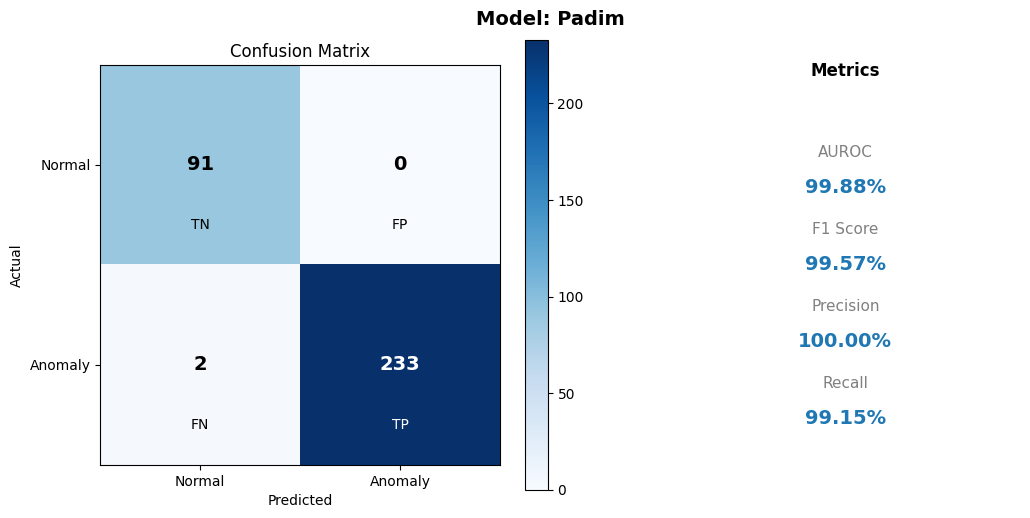

In [6]:
from plot import plot_metrics

plot_metrics("Padim", scores, pred_labels, gt_labels)

In [7]:
# AnomalÃ­as no detectadas (Falsos Negativos: gt=1, pred=0)
false_negatives = [
    item for item in items
    if item.gt_label.item() == 1 and item.pred_label.item() == 0
]

print(f"Total anomalÃ­as reales  : {gt_labels.sum().item()}")
print(f"AnomalÃ­as no detectadas : {len(false_negatives)}")
print(f"Tasa de fallo (FNR)     : {len(false_negatives) / gt_labels.sum().item():.2%}")
print()

# Ordenar por score (las mÃ¡s bajas son las mÃ¡s "normales" para el modelo)
false_negatives.sort(key=lambda x: x.pred_score.item())

print(f"{'Idx':<5} {'Score':<10} {'Path'}")
print("-" * 80)
for i, item in enumerate(false_negatives):
    print(f"{i:<5} {item.pred_score.item():<10.4f} {item.image_path}")


Total anomalÃ­as reales  : 235
AnomalÃ­as no detectadas : 2
Tasa de fallo (FNR)     : 0.85%

Idx   Score      Path
--------------------------------------------------------------------------------
0     0.2646     datasets\robotV3\test\anomaly\frame_000091.png
1     0.2759     datasets\robotV3\test\anomaly\frame_000092.png


Falsos Negativos : 2 / 235 anomalias reales  (FNR: 0.85%)
Falsos Positivos : 0 / 91 imagenes normales (FPR: 0.00%)


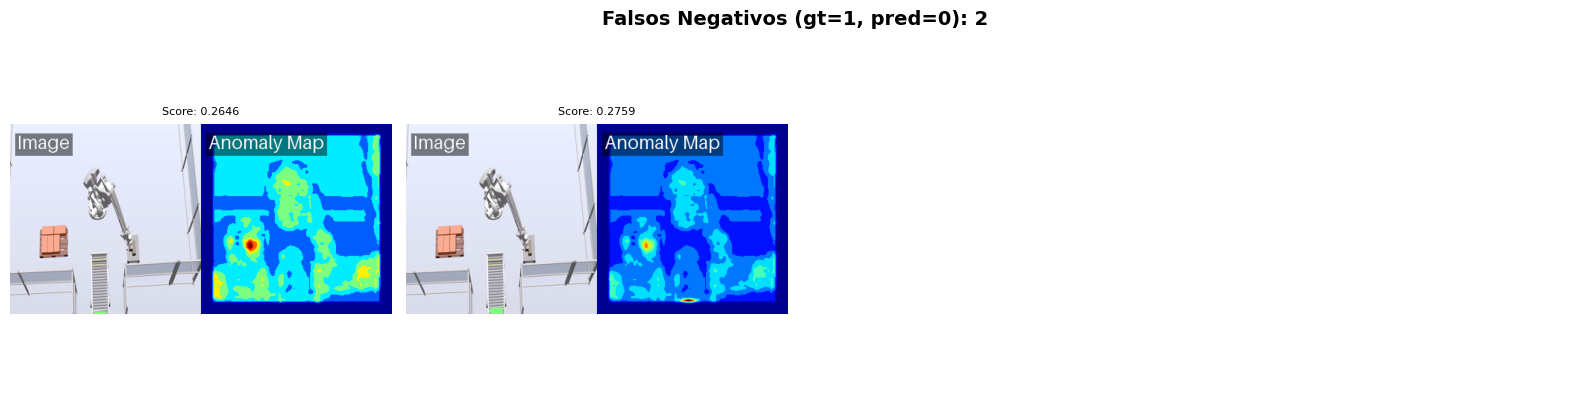

No hay Falsos Positivos (gt=0, pred=1)


In [8]:
# Falsos Negativos (gt=1, pred=0) y Falsos Positivos (gt=0, pred=1)
import math
import matplotlib.pyplot as plt
from pathlib import Path
from anomalib.visualization.image import visualize_image_item

false_negatives = [
    item for item in items
    if item.gt_label.item() == 1 and item.pred_label.item() == 0
]
false_positives = [
    item for item in items
    if item.gt_label.item() == 0 and item.pred_label.item() == 1
]

false_negatives.sort(key=lambda x: x.pred_score.item())
false_positives.sort(key=lambda x: x.pred_score.item(), reverse=True)

total_anomalias = gt_labels.sum().item()
total_normales  = (gt_labels == 0).sum().item()

print(f"Falsos Negativos : {len(false_negatives)} / {total_anomalias} anomalias reales  (FNR: {len(false_negatives)/total_anomalias:.2%})")
print(f"Falsos Positivos : {len(false_positives)} / {total_normales} imagenes normales (FPR: {len(false_positives)/total_normales:.2%})")

def visualize_group(items_list, title):
    n = len(items_list)
    if n == 0:
        print(f"No hay {title}")
        return
    cols = 4
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if n > 1 else [axes]
    for i, item in enumerate(items_list):
        vis = visualize_image_item(
            item,
            fields=["image", "anomaly_map"],
            fields_config={"anomaly_map": {"normalize": True}}
        )
        axes[i].imshow(vis)
        axes[i].set_title(f"Score: {item.pred_score.item():.4f}", fontsize=8)
        axes[i].axis("off")
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    fig.suptitle(f"{title}: {n}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

visualize_group(false_negatives, "Falsos Negativos (gt=1, pred=0)")
visualize_group(false_positives, "Falsos Positivos (gt=0, pred=1)")


In [9]:
for item in items:
    print(f"{item.image_path}: score={item.pred_score.item():.4f}")

datasets\robotV3\test\anomaly\frame_000091.png: score=0.2646
datasets\robotV3\test\anomaly\frame_000092.png: score=0.2759
datasets\robotV3\test\anomaly\frame_000093.png: score=0.5399
datasets\robotV3\test\anomaly\frame_000094.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000095.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000096.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000097.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000098.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000099.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000100.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000101.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000102.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000103.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000104.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000105.png: score=1.0000
datasets\robotV3\test\anomaly\frame_000106.png: score=0.9794
datasets\robotV3\test\an